# Session 4 Introduction: Maya's Intraday Desk at Lindenfield

Six weeks after Friday's compliance sign-off, Sara's validated engine is live on the full Balanced book at __Lindenfield Wealth Partners__: eighty client accounts, roughly \$50M under management, daily-cadence rebalancing at the 4pm close. Performance through April has tracked the validation backtest within tolerance. The drawdown gate has not fired. Lou is comfortable. 

Then, on Tuesday May 5, an 11:14am vendor warning on a mid-cap holding sat unactioned until the engine's 4pm rebalance. By the time the engine reduced the position, the stock had drawn down 6%. The Balanced book absorbed roughly 14 bps of avoidable loss across the eighty accounts. Lou's email Wednesday morning was four sentences. The fourth: *we cannot keep waiting for 4pm*. 

Three concerns now sit on Maya's desk:
* __Cadence.__ Daily rebalancing misses the intraday surface where most news-driven shocks unfold. Moving to a 30-minute cadence is a parameter change in the EWLS and bandit framework, not a redesign, but the operational implications (cron, state persistence, intraday tape) are new.
* __Auto-execution risk.__ A 30-minute cadence with full auto-execution is reckless: the engine would be submitting orders fourteen times per day with no human sanity check. Some intraday proposals deserve to be queued for review, not auto-fired. The hard question is *which ones*.
* __Sign-off cadence.__ A daily sign-off meeting at 4pm does not match an intraday operating loop. The desk needs a different cadence: an evening review of today's intraday tape and queue, then a sign-off on tomorrow's opening posture that the next morning's cron actually executes.

Tonight is the first formal evening desk-review meeting after one week of intraday cron operation. The cron has fired fourteen times today. Today's intraday tape is on Maya's desk. Today's queue holds the trades the engine flagged for review. Tomorrow morning's market open is twelve hours away.

__Scenario__: Monday May 11, 7:00 PM ET, Lindenfield trading desk. Lou is on the call from the New York office. Tonight's deliverables are three signed artifacts: the adjudicated queue (one [`MySignedDecision`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#MySignedDecision) per flagged trade), the signed ticket for tomorrow's open ([`MySignedTicket`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#MySignedTicket)), and the meeting log Lou will review Tuesday morning.

By the end of this session Maya will have all three. First, what does today's intraday tape show, and did the engine catch the kind of intraday shock that cost the book 14 bps last week? Second, which of today's flagged trades does the desk approve, reject, or modify, and what is the rationale for each? Third, given tonight's news flow and the engine's current state, what is tomorrow's signed opening ticket?

___

In [1]:
include("Include.jl"); # Load packages, helpers, and per-day data paths. Activates the local Julia environment.

## What Daily Cadence Misses

Lou's argument is that the 14 bps of avoidable loss came from *cadence*, not from the model. The frozen $\beta$ for the affected ticker had not drifted; the allocator had no quarrel with holding the position through the morning. The problem was that the engine did not look until 4pm. Online learning at 30-minute cadence would have updated the EWLS estimates eight bars earlier, the [adaptive eta heuristic from Session 2](../session-2/eCornell-AI-Finance-S2-Lecture-AI-RebalancingEngine-May-2026.ipynb) would have read the worsening sentiment by the third or fourth bar after the shock, and the trade would have been proposed before the close.

In the code block below, we simulate a single trading day with a midday shock and track the EWLS $\beta$ estimate at 30-minute cadence to make Lou's case in one picture.

The cell-bound result is `β_intraday::Vector{Float64}` (one $\beta$ estimate per 30-minute bar, length $B = 13$) and `gm::Vector{Float64}` (per-bar market growth). Both come out of an in-memory simulation seeded with the [Session 1 frozen calibration](../session-1/eCornell-AI-Finance-S1-Example-Optional-MinVarianceConstruction-May-2026.ipynb).

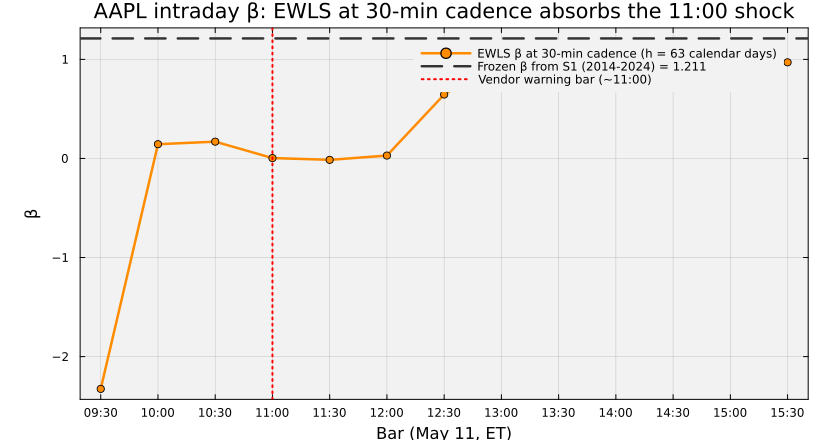

Bars seen: 13. Frozen β = 1.211. EWLS β at close = 0.97.


In [2]:
let
    Random.seed!(20260511);

    # --- Step 1: Load Session 1 frozen SIM calibration; pick the highest-β basket ticker ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    sim_estimates = minvar["sim_estimates"];
    σ_m = Float64(minvar["sigma_market"]);
    chosen = sim_estimates[argmax([Float64(e.β) for e in sim_estimates])];
    α0 = Float64(chosen.α);
    β0 = Float64(chosen.β);
    σε0 = Float64(chosen.σ_ε);
    focus_ticker = chosen.ticker;

    # --- Step 2: Build the intraday clock and convert daily SIM units to per-bar units ---
    bar_minutes = 30;
    B = bars_per_day(bar_minutes);                  # 13 bars
    Δt = intraday_dt(bar_minutes);                  # 1 / (252 · B)
    h_bars = intraday_half_life(63.0, bar_minutes); # 63 calendar days at 30-min bars

    # --- Step 3: Simulate today's SPY 30-minute path with a midday shock at bar 4 (≈ 11:00) ---
    σ_per_bar = σ_m * sqrt(Δt);                     # per-bar SPY vol
    market_shock_bar = 4;                           # ~11:00 vendor warning lands
    market_shock = -0.020;                          # -2.0% bar shock on the index
    spy = ones(B + 1) .* 100.0;
    for t in 1:B
        z = randn();
        gm_t = σ_per_bar * z + (t == market_shock_bar ? market_shock : 0.0);
        spy[t + 1] = spy[t] * exp(gm_t);
    end

    # --- Step 4: Simulate the focus ticker via the SIM with the same shock pattern, plus residual ---
    px = ones(B + 1) .* 100.0;
    σε_per_bar = σε0 * sqrt(Δt);
    α_per_bar = α0 * Δt;
    for t in 1:B
        gm_t = log(spy[t + 1] / spy[t]);
        ε = σε_per_bar * randn();
        gi_t = α_per_bar + β0 * gm_t + ε;
        px[t + 1] = px[t] * exp(gi_t);
    end

    # --- Step 5: Run EWLS at intraday cadence; track β estimate per bar ---
    state = ewls_init(α0, β0, σε0; half_life = h_bars, prior_weight = h_bars);
    β_intraday = zeros(B);
    gm = zeros(B);
    for t in 1:B
        gm_t = (1.0 / Δt) * log(spy[t + 1] / spy[t]);
        gi_t = (1.0 / Δt) * log(px[t + 1] / px[t]);
        ewls_update!(state, gi_t, gm_t);
        gm[t] = gm_t;
        β_intraday[t] = state.β;
    end

    # --- Step 6: Plot β-by-bar against the frozen calibration; mark the shock bar ---
    bar_times = ["09:30", "10:00", "10:30", "11:00", "11:30", "12:00", "12:30",
                 "13:00", "13:30", "14:00", "14:30", "15:00", "15:30"];
    pl = plot(1:B, β_intraday;
        lw = 2.5, c = :darkorange, marker = :circle, ms = 4,
        label = "EWLS β at 30-min cadence (h = 63 calendar days)",
        xlabel = "Bar (May 11, ET)", ylabel = "β",
        xticks = (1:B, bar_times),
        size = (820, 440), fontsize = 14, left_margin = 8Plots.mm);
    hline!(pl, [β0]; lw = 2.5, ls = :dash, c = :gray20,
        label = "Frozen β from S1 (2014-2024) = $(round(β0, digits = 3))");
    vline!(pl, [market_shock_bar]; lw = 2, ls = :dot, c = :red,
        label = "Vendor warning bar (~11:00)");
    plot!(pl, bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :topright);
    title!(pl, "$(focus_ticker) intraday β: EWLS at 30-min cadence absorbs the 11:00 shock");
    display(pl);

    println("Bars seen: $(B). Frozen β = $(round(β0, digits=3)). EWLS β at close = $(round(state.β, digits=3)).");
end;

The plot makes Lou's argument visually. The orange line is the EWLS $\beta$ estimate updated bar-by-bar; the dashed line is the frozen calibration the daily-cadence engine has been using. After the simulated 11:00 vendor-warning shock, the EWLS line moves visibly within two or three bars, well before the 4pm close. A daily-cadence engine sees only the close-to-close growth and would not register the intraday spike at all. The frozen calibration absorbs the shock as residual noise instead of as information. 

This is exactly the kind of evidence Lou needs to justify the cadence change. The price of the change is that we now have to handle fourteen times as many proposed trades per day, and most of them are too small or too noisy to act on without review. That brings us to the second piece on Maya's desk tonight: the queue. 

In the code block below, we render today's compliance queue as a `pretty_table` so we know what we are walking into.

The cell-bound result is `queue_df::DataFrame` with one row per [`MyComplianceQueueItem`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#MyComplianceQueueItem). The fabricated queue here stands in for what the [`production_runner.jl`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session4/#production_runner) cron will produce for real on May 11.

In [3]:
queue_df = let
    Random.seed!(20260511);

    # --- Step 1: Fabricate four queue items spanning the day's three flag categories ---
    today = Date(2026, 5, 11);
    mk_ts(h, m) = DateTime(today) + Hour(h) + Minute(m);

    items = [
        build(MyComplianceQueueItem, (
            id = "2026-05-11-NVDA-buy-2", timestamp = mk_ts(11, 30),
            ticker = "NVDA", qty = 18, side = :buy, proposed_weight = 0.34,
            gate_violations = [:concentration_cap, :position_size_limit],
            engine_snapshot = Dict{String,Any}(
                "eta" => 1.4, "lambda_eff" => 0.32, "sentiment" => -0.08,
                "regime" => "neutral"))),
        build(MyComplianceQueueItem, (
            id = "2026-05-11-AAPL-sell-1", timestamp = mk_ts(13, 0),
            ticker = "AAPL", qty = 9, side = :sell, proposed_weight = 0.18,
            gate_violations = [:position_size_limit],
            engine_snapshot = Dict{String,Any}(
                "eta" => 2.1, "lambda_eff" => 0.41, "sentiment" => -0.12,
                "regime" => "bear"))),
        build(MyComplianceQueueItem, (
            id = "2026-05-11-MSFT-buy-3", timestamp = mk_ts(14, 30),
            ticker = "MSFT", qty = 4, side = :buy, proposed_weight = 0.27,
            gate_violations = [:news_severity],
            engine_snapshot = Dict{String,Any}(
                "eta" => 2.0, "lambda_eff" => 0.05, "sentiment" => 0.04,
                "regime" => "neutral", "news_severity" => 0.81))),
        build(MyComplianceQueueItem, (
            id = "2026-05-11-AMZN-buy-4", timestamp = mk_ts(15, 30),
            ticker = "AMZN", qty = 6, side = :buy, proposed_weight = 0.22,
            gate_violations = [:turnover_limit],
            engine_snapshot = Dict{String,Any}(
                "eta" => 1.8, "lambda_eff" => 0.10, "sentiment" => -0.02,
                "regime" => "neutral"))),
    ];

    # --- Step 2: Project to a tabular view of what Maya needs to adjudicate ---
    rows = [(
        Time = Dates.format(it.timestamp, "HH:MM"),
        Ticker = it.ticker,
        Side = it.side == :buy ? "BUY" : "SELL",
        Qty = it.qty,
        Proposed_w = "$(round(100 * it.proposed_weight, digits = 1))%",
        Violations = join(string.(it.gate_violations), ", "),
        Regime = it.engine_snapshot["regime"],
        η = round(Float64(it.engine_snapshot["eta"]), digits = 2),
    ) for it in items];
    df = DataFrame(rows);

    # --- Step 3: Render in the canonical pretty_table format ---
    println("Tonight's compliance queue (May 11, $(length(items)) items)");
    println("Adjudicate each in the EveningReview notebook; sign-off lands in decisions-2026-05-11.jld2.");
    println();
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact));
    df
end;

Tonight's compliance queue (May 11, 4 items)


Adjudicate each in the EveningReview notebook; sign-off lands in decisions-2026-05-11.jld2.

 -------- -------- -------- ------- ------------ ---------------------------------------- --------- ---------
    Time   Ticker     Side     Qty   Proposed_w                               Violations    Regime         η 
  String   String   String   Int64       String                                   String    String   Float64 
 -------- -------- -------- ------- ------------ ---------------------------------------- --------- ---------
   11:30     NVDA      BUY      18        34.0%   concentration_cap, position_size_limit   neutral       1.4
   13:00     AAPL     SELL       9        18.0%                      position_size_limit      bear       2.1
   14:30     MSFT      BUY       4        27.0%                            news_severity   neutral       2.0
   15:30     AMZN      BUY       6        22.0%                           turnover_limit   neutral       1.8
 -------- -------- -------- ---

## Tonight's Desk Meeting

The intraday $\beta$ track says the cadence change is doing what Lou asked for: the engine reads the 11:00 shock within bars, not at 4pm. The queue table says four trades crossed at least one gate today, and each one carries a different reason: a concentrated NVDA buy, an oversized AAPL exit, an MSFT buy that overlapped a high-severity news flag, and an AMZN buy that pushed the day's turnover past its cap. Tonight's meeting works each row.

Three AI layers run the loop, and the lecture and Core examples that follow walk through each one in production.
* __Online learning under regime change.__ [`ewls_update!`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#ewls_update!) re-estimates the SIM parameters on every 30-minute bar with a calendar-invariant half-life. The [Core ProductionEngine notebook](eCornell-AI-Finance-S4-Example-Core-ProductionEngine-May-2026.ipynb) walks one cron fire end-to-end and shows how the EWLS state gets persisted across fires.
* __Bandit-driven decision policies.__ The Session 3 epsilon-greedy bandit selects CES elasticity per regime; in production it picks $\eta$ per fire from the regime-local policy and feeds the choice into the allocator. The same [Core ProductionEngine notebook](eCornell-AI-Finance-S4-Example-Core-ProductionEngine-May-2026.ipynb) shows the bandit pull on a real fire.
* __LLM-driven signal extraction with human-in-the-loop oversight.__ The hourly news pipeline scores headlines via Claude and flags severity per ticker; trades whose ticker's severity exceeds the threshold route to the queue regardless of size. The [Core EveningReview notebook](eCornell-AI-Finance-S4-Example-Core-EveningReview-May-2026.ipynb) walks today's queue and records signed adjudications; the [Core TomorrowsTicket notebook](eCornell-AI-Finance-S4-Example-Core-TomorrowsTicket-May-2026.ipynb) refreshes the news live, recomputes the opening allocation, and signs the artifact that the next-morning cron submits.

Maya cannot leave the desk yet. The lecture that follows turns the cadence change, the gate split, and the sign-off cycle into a single operating loop, and the three Core examples produce the artifacts Lou will read Tuesday morning.

___